In [1]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preprocessing

In [2]:
# Load the data
student = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
# check the data
student.info()
student.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
student.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
# do we have duplicates
print(student.duplicated().sum())

0


We have information of 6077 unique students in the data. There are 20 columns covering factors associated with school (e.g. School_Type), family (e.g. Parental_Education_Level) and student self(e.g. Hours_Studied). 7 columns (including the target "Exam_Score") contains numerical values and 13 columns contains categorical values.  

We have found missing values in columns "Teacher_Quality", "Parental_Education_Level" and "Distance_from_Home".  

We do not see unrealistic values in numerical columns but there are cases which student score 101. We should check that because it is more likely that the full score is 100. This could be an data entry error.

In [6]:
# let's check the numerical values first
# check for outliers
# correct that 101 score

# check outliers using IQR method
# get all the numerical columns
nume_cols = student.select_dtypes(include="number")

for col in nume_cols:
    Q1 = nume_cols[col].quantile(0.25)
    Q3 = nume_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = nume_cols[(nume_cols[col] < lower_bound) | (nume_cols[col] > upper_bound)]
    
    if len(outliers) == 0:
        print(f"There is no outlier in {col}\n")
    else:
        print(f'There is/are {len(outliers)} in {col}')
       # print(outliers)
        print()

There is/are 43 in Hours_Studied

There is no outlier in Attendance

There is no outlier in Sleep_Hours

There is no outlier in Previous_Scores

There is/are 430 in Tutoring_Sessions

There is no outlier in Physical_Activity

There is/are 104 in Exam_Score



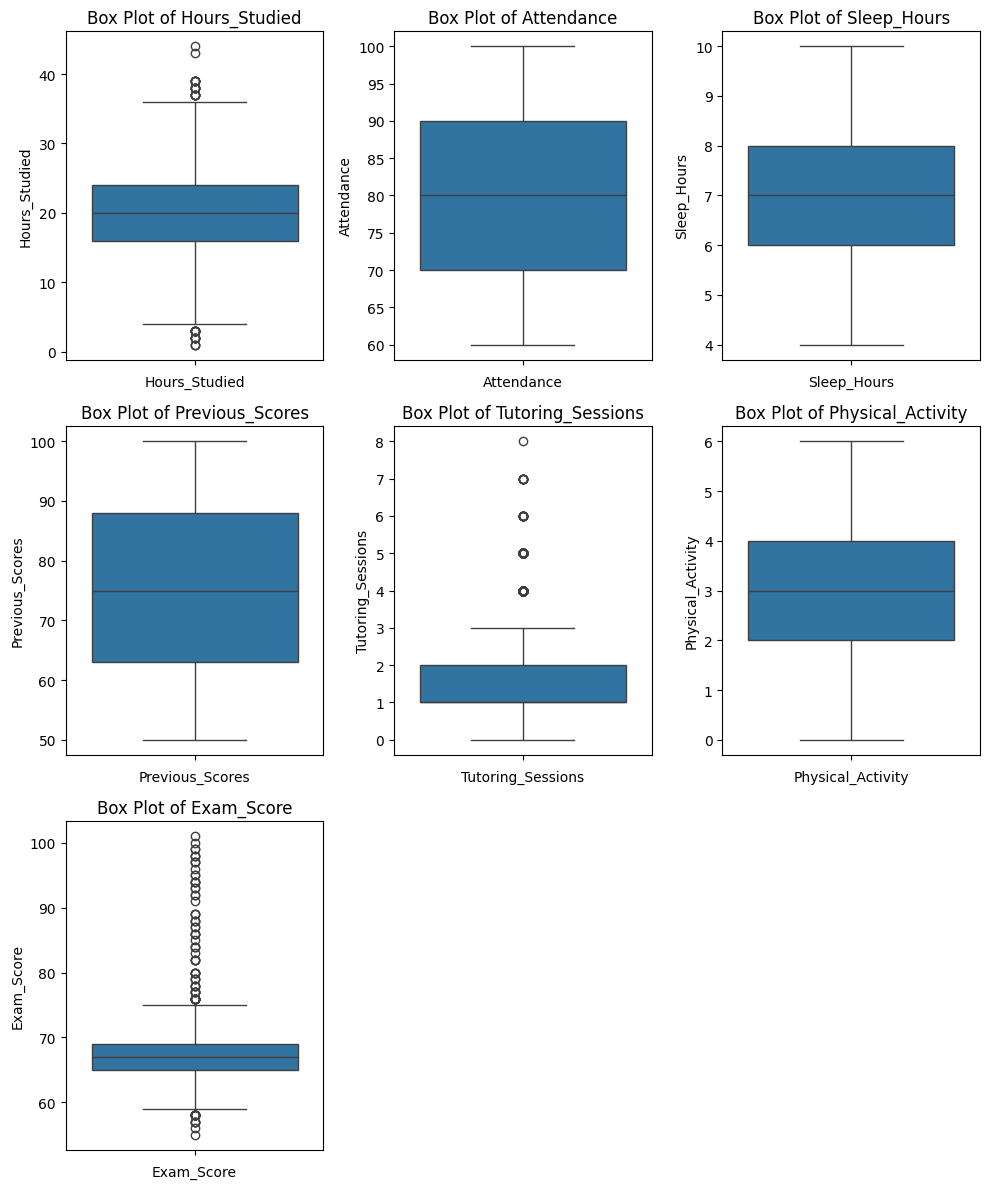

In [7]:
# use box plots to view outliers
# use smallmultiples to show all plots together

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 12))
axes = axes.flatten()

# Plot histograms for every column
for i, col in enumerate(nume_cols):
    sns.boxplot(y=nume_cols[col],ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    
# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Although we see "outliers", they are not unrealistic values. Many students study for about 20 hours per week, but it is still normal for some students to study for 40 hours. Simlarly, for Tutoring_Sessions and Exam_Score, having as many as 8 tutoring session is as normal as having 2 based on the family's income and as long as we don't see scores under 0 or greater than 100, there should be no problem. We will not remove the "outliers".

In [8]:
# but, check which student(s) has the score 101
student[student.Exam_Score == 101]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [9]:
# yes, that is very likely a mistake
# update the score to 100(full score)
student.loc[student["Exam_Score"] == 101, "Exam_Score"] = 100

In [12]:
# check that student again
student.iloc[1525]

Hours_Studied                          27
Attendance                             98
Parental_Involvement                  Low
Access_to_Resources                Medium
Extracurricular_Activities            Yes
Sleep_Hours                             6
Previous_Scores                        93
Motivation_Level                      Low
Internet_Access                        No
Tutoring_Sessions                       5
Family_Income                        High
Teacher_Quality                      High
School_Type                        Public
Peer_Influence                   Positive
Physical_Activity                       3
Learning_Disabilities                  No
Parental_Education_Level      High School
Distance_from_Home               Moderate
Gender                             Female
Exam_Score                            100
Name: 1525, dtype: object

In [13]:
# now, we move on to categorical columns
# check the 3 columns with missing values Teacher_Quality, Parental_Education_Level, Distance_from_Home

print(student.Teacher_Quality.value_counts())
print()

print(student.Parental_Education_Level.value_counts())
print()

print(student.Distance_from_Home.value_counts())

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64


In [14]:
# as these are all categorical values, we can use Mode/most frequent value to impute the missing values.
student.Teacher_Quality = student.Teacher_Quality.fillna("Medium")

student.Parental_Education_Level = student.Parental_Education_Level.fillna("High School")

student.Distance_from_Home = student.Distance_from_Home.fillna("Near")

In [15]:
# check the imputation
print(student.Teacher_Quality.value_counts())
print()

print(student.Parental_Education_Level.value_counts())
print()

print(student.Distance_from_Home.value_counts())

Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64

Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near        3951
Moderate    1998
Far          658
Name: count, dtype: int64


## Visualization

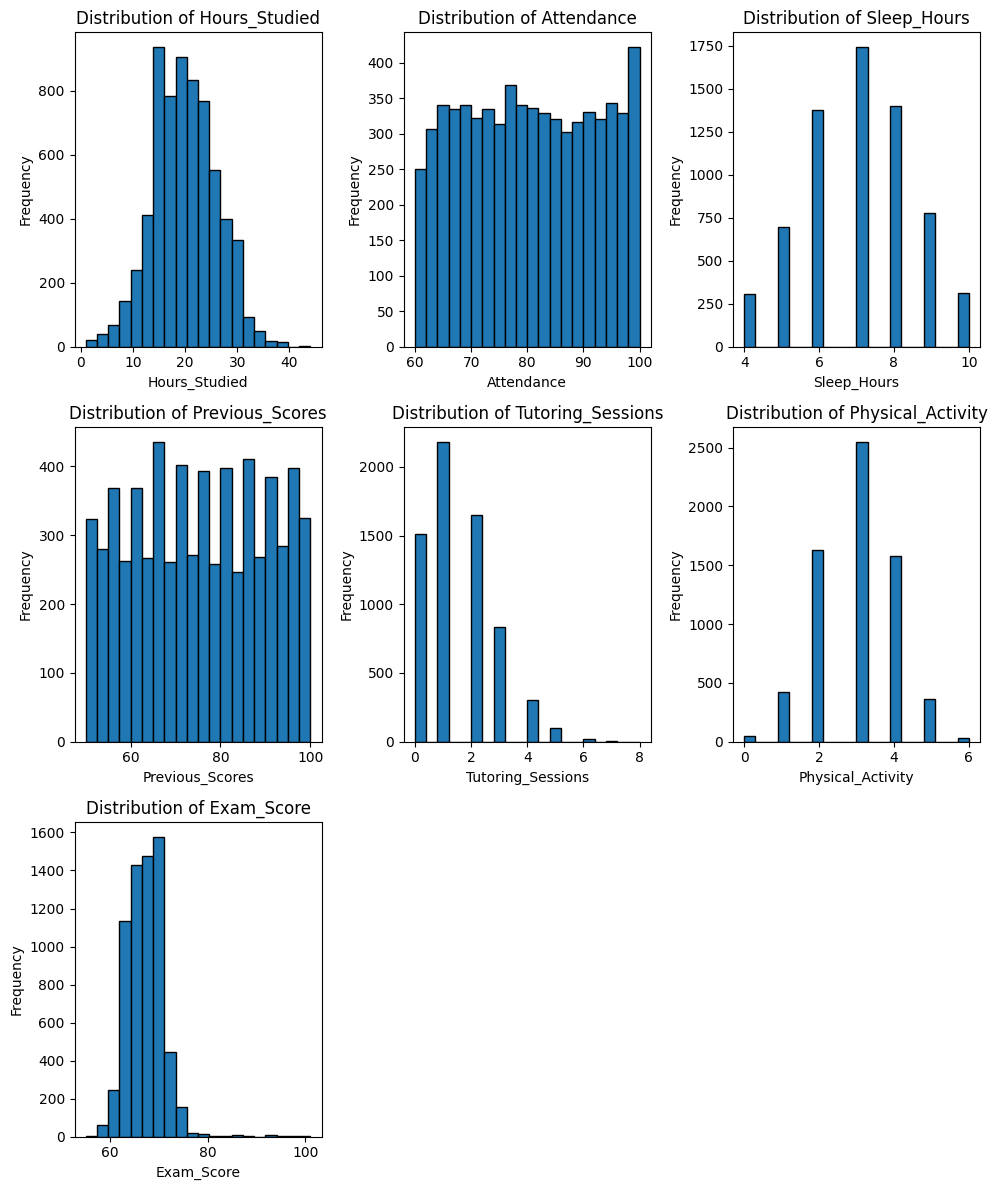

In [16]:
# create histogram for numerical columns

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 12))
axes = axes.flatten()

# Plot histograms for every column
for i, col in enumerate(nume_cols):
    axes[i].hist(nume_cols[col].dropna(), bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Most students study about 15-25 hous per week and it is rare to study for less than 10 hours(with the minimum values at 1) or more than 30 hours(withe the maximum value at 44).  

All students managed to reach over 60% attendance rate.  

Most students sleep for at least 7 hours a day.  

Most students has no more than 2 tutoring session possibly due to high expenses.

Most students has 2-4 hours of daily physical activities.

As we compare the distribution of previous scores to exam scores, it is found that the number of students with "relatively good score"(>= 80) and "relatively low score"(<= 60) significately dropped in the current exam. In the previous exam, there were more than 300 students who got (almost) the full score. But in the current exam, most studnets scored around 70 and almost no student scored over 80.

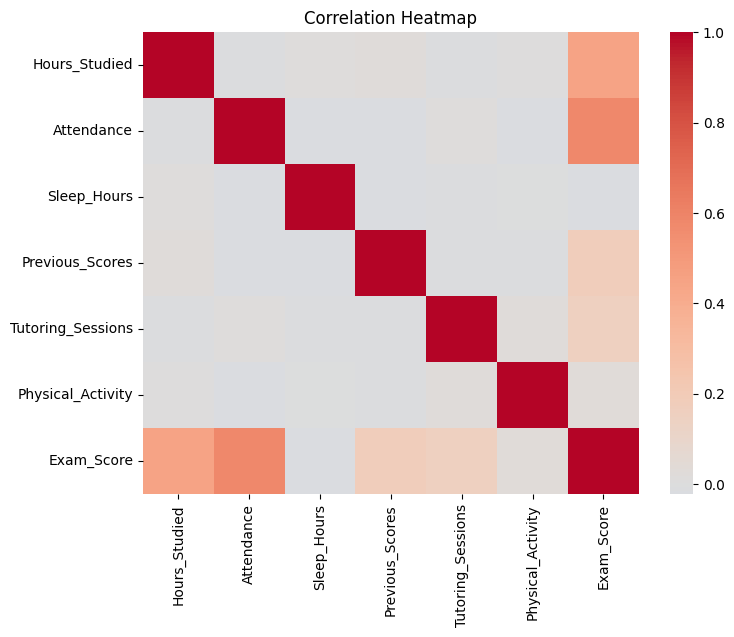

In [17]:
# Compute correlation matrix
corr = student.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

Based on the correlation heatmap, it makes sense that students who invest more time, attend courses more actively, score high previously and receiving more help from tutors can score higher.  
We do find week positive correlation between for example, Sleep_Hours and Hours_Studied.

In [18]:
# create a table to check all unique values in categorical columns
unique = pd.DataFrame({
    'n_unique': student.select_dtypes('object').nunique(),
    'sample_values': student.select_dtypes('object').apply(lambda x: x.unique())
})

display(unique)

,n_unique,sample_values
Parental_Involvement,3,"[Low, Medium, High]"
Access_to_Resources,3,"[High, Medium, Low]"
Extracurricular_Activities,2,"[No, Yes]"
Motivation_Level,3,"[Low, Medium, High]"
Internet_Access,2,"[Yes, No]"
Family_Income,3,"[Low, Medium, High]"
Teacher_Quality,3,"[Medium, High, Low]"
School_Type,2,"[Public, Private]"
Peer_Influence,3,"[Positive, Negative, Neutral]"
Learning_Disabilities,2,"[No, Yes]"


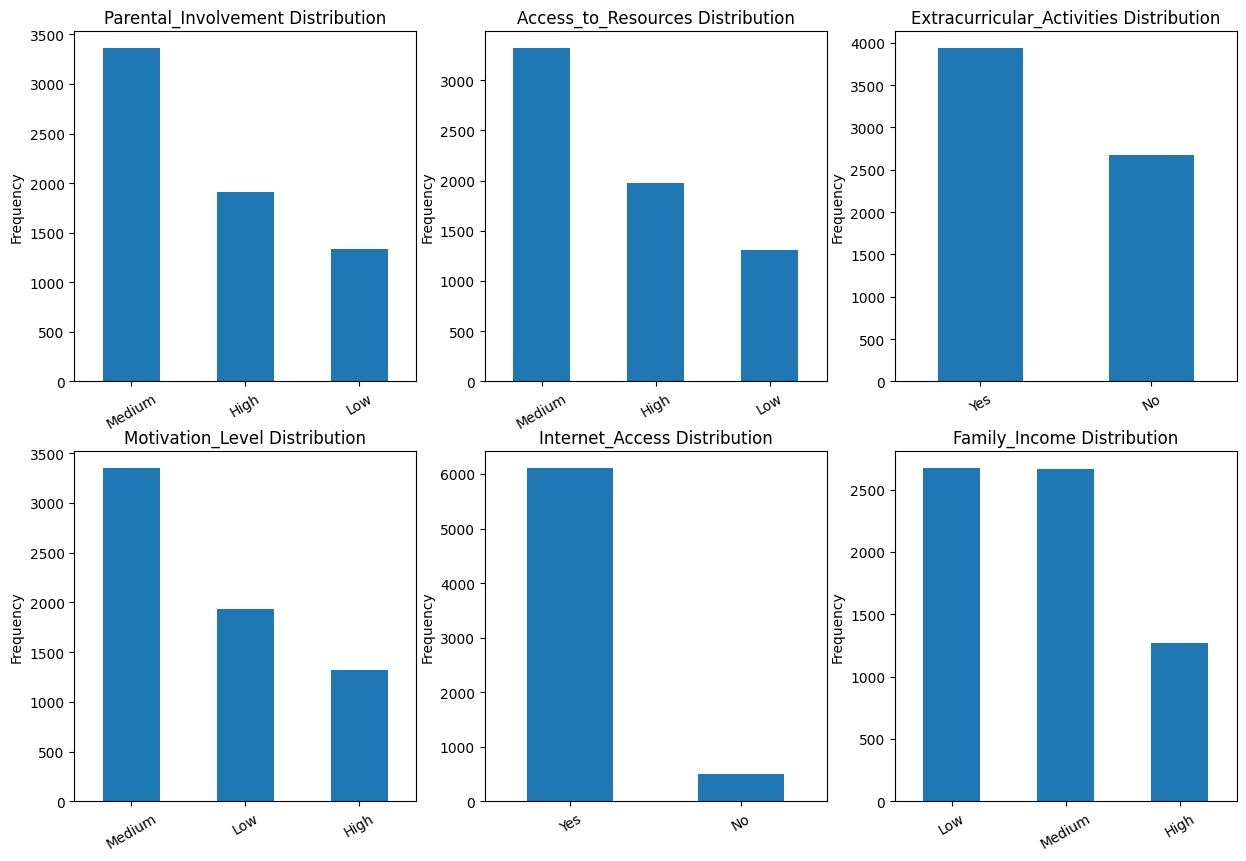

In [29]:
# let's look at the categorical columns
# get the columns
cat_cols = student.drop(columns=nume_cols.columns)
cols = cat_cols.columns.tolist()

# Take only 6 columns
subset = cols[:6]

# layout
n_cols = 3
n_rows = 2

# same y axis for every plot
# max_count = max(cat_cols[col].value_counts().max() for col in subset)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(subset):
    counts = cat_cols[col].value_counts()
    counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()
plt.close(fig)

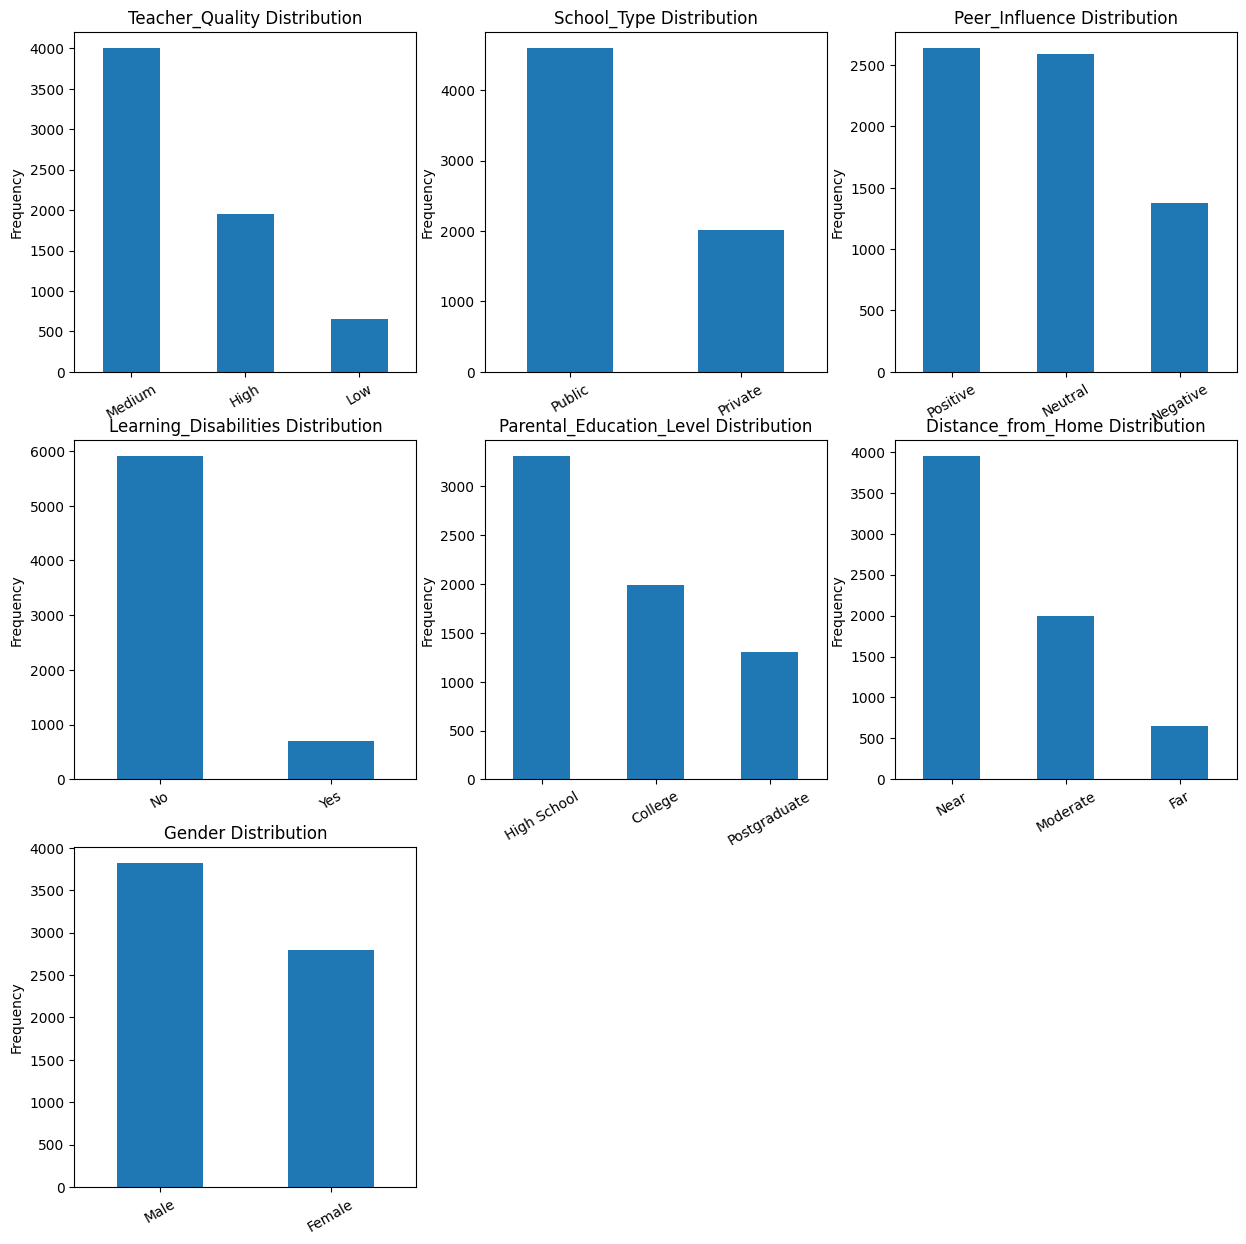

In [30]:
# do the same for the rest 7 categorical columns
# Take only 6 columns
subset = cols[6:]

# layout
n_cols = 3
n_rows = 3

# same y axis for every plot
# max_count = max(cat_cols[col].value_counts().max() for col in subset)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(subset):
    counts = cat_cols[col].value_counts()
    counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlabel("")
    #axes[i].set_ylim(0, max_count)
    axes[i].tick_params(axis="x", rotation=30)

# Turn off any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()
plt.close(fig)

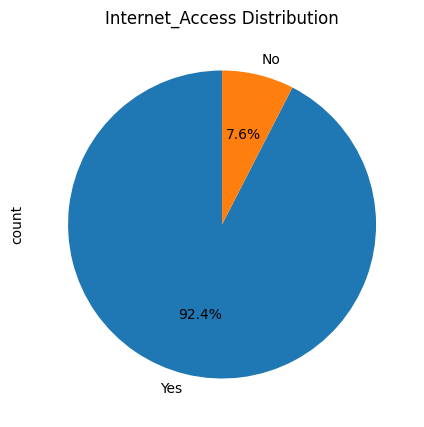

In [31]:
# create pie charts to see percentage in Internet_Access and Learning_Disability
# count values
counts = student.Internet_Access.value_counts()

# Create pie chart
plt.figure(figsize=(5, 5))
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Internet_Access Distribution")
plt.show()

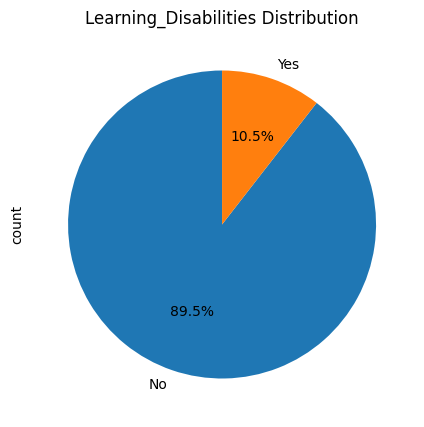

In [33]:
# count values
counts = student.Learning_Disabilities.value_counts()

# Create pie chart
plt.figure(figsize=(5, 5))
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Learning_Disabilities Distribution")
plt.show()

We have more male students than female student but the difference is not extreme.  

In general, having medium level of parental involvement, access to resources, motivation level and teacher quality is most common. Most students attend public schools, love close to schools and have low or medium family income.  

The most common education level of parents are high school.

Most student did not report having nagative influence from peers.

About 8% of students does not have access to Internet. Only about 10% of students reports having study disabilities.

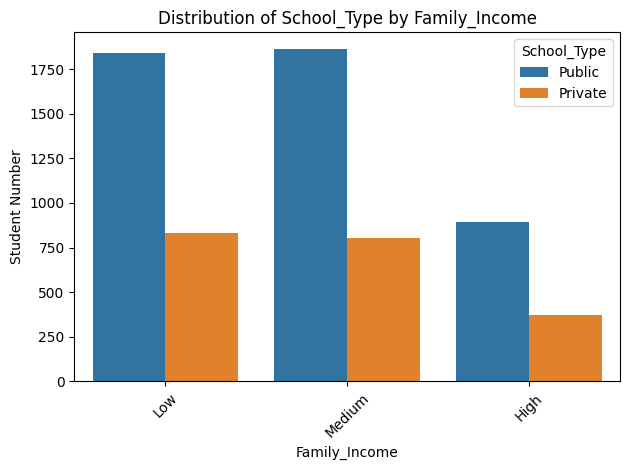

In [34]:
# check the relationshop between family income and school type
sns.countplot(data = student, x = 'Family_Income', hue = 'School_Type')
plt.title('Distribution of School_Type by Family_Income')
plt.ylabel('Student Number')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

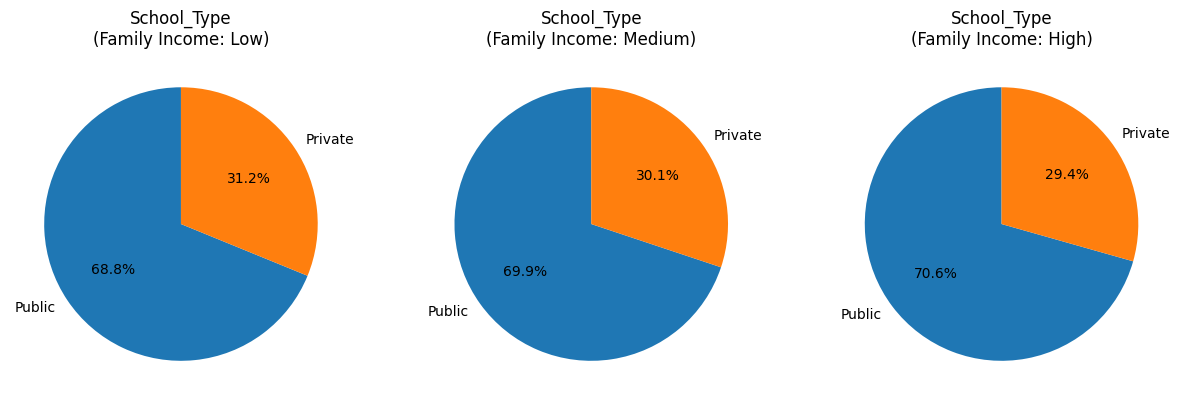

In [38]:
# try pie charts

# set the order from low to high
income_levels = ["Low", "Medium", "High"]

fig, axes = plt.subplots(1, len(income_levels), figsize=(15, 5))

for ax, income in zip(axes, income_levels):
    income_n_school = (student[student["Family_Income"] == income]["School_Type"].value_counts())

    ax.pie(
        income_n_school,
        labels=income_n_school.index,
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"School_Type\n(Family Income: {income})")

plt.show()

Even for students with high family income, there is no pattern of them enrolled in private schools more. Regardless of family income level, most students still attend public schools. 

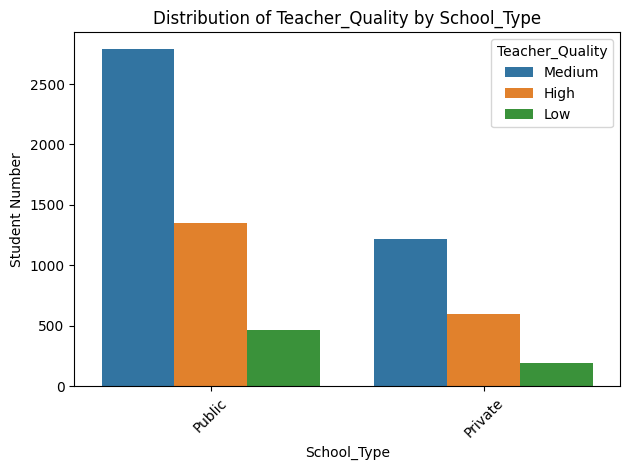

In [35]:
# can private schools have better teachers(in terms of quality)?
sns.countplot(data = student, x = 'School_Type', hue = 'Teacher_Quality')
plt.title('Distribution of Teacher_Quality by School_Type')
plt.ylabel('Student Number')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

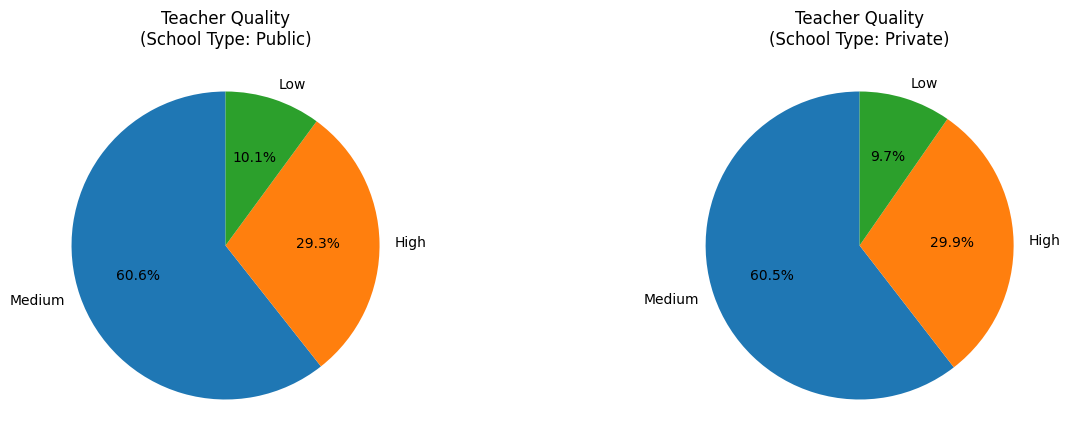

In [40]:
# try pie charts

# set the order
school_type = ["Public", "Private"]

fig, axes = plt.subplots(1, len(school_type), figsize=(15, 5))

for ax, school in zip(axes, school_type):
    school_n_teacher = (student[student["School_Type"] == school]["Teacher_Quality"].value_counts())

    ax.pie(
        school_n_teacher,
        labels=school_n_teacher.index,
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"Teacher Quality\n(School Type: {school})")

plt.show()

There is no clear pattern of private school having more high quality teachers. The difference does exist but remains scarce.

## Prepare Data for Models

In [53]:
# make a copy
student_data = student.copy()

In [43]:
# refresh the memory
display(unique) # this is a table we have created before to show all unique values in categorical columns

,n_unique,sample_values
Parental_Involvement,3,"[Low, Medium, High]"
Access_to_Resources,3,"[High, Medium, Low]"
Extracurricular_Activities,2,"[No, Yes]"
Motivation_Level,3,"[Low, Medium, High]"
Internet_Access,2,"[Yes, No]"
Family_Income,3,"[Low, Medium, High]"
Teacher_Quality,3,"[Medium, High, Low]"
School_Type,2,"[Public, Private]"
Peer_Influence,3,"[Positive, Negative, Neutral]"
Learning_Disabilities,2,"[No, Yes]"


In [54]:
# for gender, create new column "female"(0/1)
student_data['Female'] = student_data['Gender'].map({'Female': 1, 'Male': 0})

In [55]:
# update "Yes" & "No" values to 1 and 0
student_data['Extracurricular_Activities'] = student_data['Extracurricular_Activities'].map({'Yes': 1, 'No': 0})
student_data['Internet_Access'] = student_data['Internet_Access'].map({'Yes': 1, 'No': 0})
student_data['Learning_Disabilities'] = student_data['Learning_Disabilities'].map({'Yes': 1, 'No': 0})

In [56]:
# do one-hot encoding for the rest of the columns
# it is clear that most values in these columns have orders like from low to high, near to far
# but it is more appropriate to use one-hot encoding(because we will use linear/ridge regression) than giving them values like 1-3
# Columns to exclude from one-hot encoding
exclude = ["Extracurricular_Activities", "Internet_Access", "Learning_Disabilities", "Female", "Gender"]

# take all categorical columns
cat_cols = student_data.select_dtypes(include="object").columns

# exclude the processed columns and perform one-hot encoding
for col in list(cat_cols):
    if col not in exclude:
        student_data = pd.get_dummies(student_data, columns=[col], dtype = 'int') # get 1/0

In [57]:
# check the data
student_data.iloc[8]

Hours_Studied                              17
Attendance                                 94
Extracurricular_Activities                  0
Sleep_Hours                                 6
Previous_Scores                            80
Internet_Access                             1
Tutoring_Sessions                           0
Physical_Activity                           1
Learning_Disabilities                       0
Gender                                   Male
Exam_Score                                 69
Female                                      0
Parental_Involvement_High                   0
Parental_Involvement_Low                    0
Parental_Involvement_Medium                 1
Access_to_Resources_High                    1
Access_to_Resources_Low                     0
Access_to_Resources_Medium                  0
Motivation_Level_High                       1
Motivation_Level_Low                        0
Motivation_Level_Medium                     0
Family_Income_High                

In [58]:
# drop unneeded columns
student_data.drop(columns = ['Gender'], axis = 1, inplace = True)

## Models

In [59]:
from sklearn.preprocessing import StandardScaler # scale numerical columns
from sklearn.compose import ColumnTransformer 

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # 8:2 split of the data

from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV # test with different alpha in Ridge regression

In [60]:
# split the train/test data
X = student_data.drop(columns = ['Exam_Score'])
y = student_data.Exam_Score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression & Ridge Regression

In [61]:
# create a preprocessor for scaling

# specify the columns to be scaled
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols) # only use the standard scaler on the columns specified
    ],
    remainder="passthrough"   # keep other columns unchanged
)

In [67]:
# create the pipeline
linear= Pipeline([
        ("preprocess", preprocessor),
        ("linear", LinearRegression())
])

ridge = Pipeline([
    ("preprocess", preprocessor),
    ('ridge', RidgeCV(alphas=[0.1, 1, 10, 100])) # use RidgeCV so that we can test different alpha
])

In [68]:
# fit the training data
linear.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
ridge.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
# make prediction using test data
pred_lin = linear.predict(X_test)
pred_rid = ridge.predict(X_test)

In [71]:
# Evaluation using Mean Square Error and R^2
#linear
mse_linear = mean_squared_error(y_test, pred_lin)
r2_linear = r2_score(y_test, pred_lin)

# ridge
mse_ridge = mean_squared_error(y_test, pred_rid)
r2_ridge = r2_score(y_test, pred_rid)

# print the results
print("Linear Regression")
print(f"Linear Regression   Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression   R^2 Score: {r2_linear:.2f}")
print("\n")

print("Ridge Regression")
print(f"Ridge Regression   Mean Squared Error: {mse_ridge:.2f}")
print(f"Ridge Regression   R^2 Score: {r2_ridge:.2f}")

Linear Regression
Linear Regression   Mean Squared Error: 3.26
Linear Regression   R^2 Score: 0.77


Ridge Regression
Ridge Regression   Mean Squared Error: 3.25
Ridge Regression   R^2 Score: 0.77


In [72]:
# when the alpha value is small, the model should work similar to linear regression
print(ridge.named_steps['ridge'].alpha_)

10.0


Ridge Regression performs similarly as Linear Regression.This is becuase there is no strong correlation between variables. Ridge Regression can improve the performance when multicollinearity exist and when we have many features but we expect most of them has little(not 0) contribution to the target. For the current case, Linear Regression already performs decently with R square at 0.77 (the closer to 1 the better).

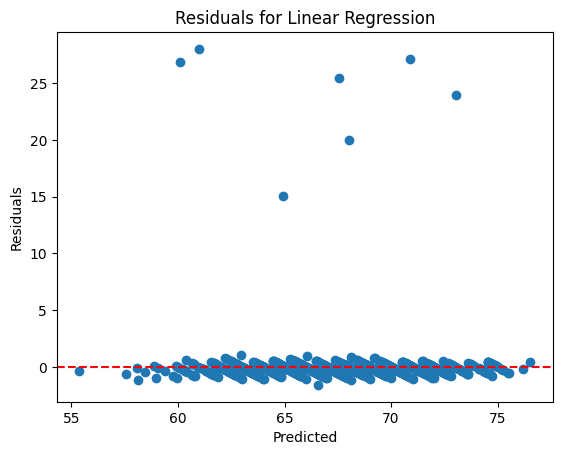

In [74]:
# create residual plot
residuals = y_test - pred_lin

# Plot
plt.scatter(pred_lin, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals for Linear Regression')
plt.show()

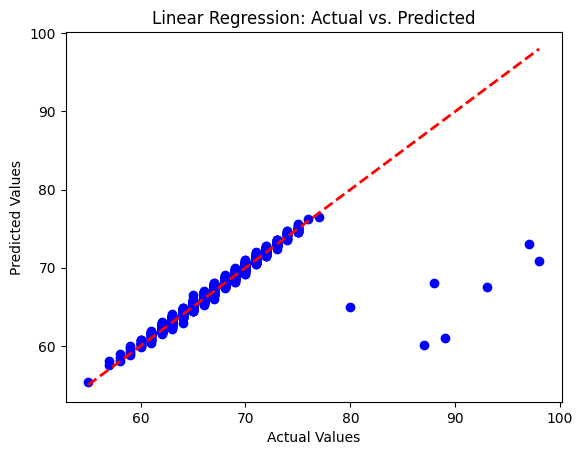

In [75]:
# plots of predicted values vs actual values

# linear regression
plt.scatter(y_test, pred_lin, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.title('Linear Regression: Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In most cases, the linear model did quite well. Some exceptions are that a very small group of students performed better than the model preditced (e.g. scoring almost 100 but the model expecte the socre to be about 70).

### Random Forest

In [77]:
from sklearn.ensemble import RandomForestRegressor

# create the basic random forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)

# fit the training data
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
# evaluate using the test data
pred_rf = rf.predict(X_test)

# print the MSE and R squared
mse_rf = mean_squared_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

# print the results
print("Random Forest")
print(f"Random Forest   Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest   R^2 Score: {r2_rf:.2f}")

Random Forest
Random Forest   Mean Squared Error: 4.71
Random Forest   R^2 Score: 0.67


In [79]:
# try tuning using GridSearch
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
# fit on training data to find the best parameters
grid_rf.fit(X_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)

Best Random Forest Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [80]:
# create the tuned random forest model
best_rf = RandomForestRegressor(
    max_depth=None,
    min_samples_leaf=4,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

# fit the training data
best_rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
# evaluate again
pred_best_rf = best_rf.predict(X_test)

# print the MSE and R squared
mse_best_rf = mean_squared_error(y_test, pred_best_rf)
r2_best_rf = r2_score(y_test, pred_best_rf)

# print the results
print("Random Forest(Tuned)")
print(f"Random Forest(Tuned)   Mean Squared Error: {mse_best_rf:.2f}")
print(f"Random Forest(Tuned)   R^2 Score: {r2_best_rf:.2f}")

Random Forest(Tuned)
Random Forest(Tuned)   Mean Squared Error: 4.38
Random Forest(Tuned)   R^2 Score: 0.69


In [82]:
print("Train R²:", best_rf.score(X_train, y_train))
print("Test R²:", best_rf.score(X_test, y_test))

Train R²: 0.806274453488964
Test R²: 0.6898286875584779


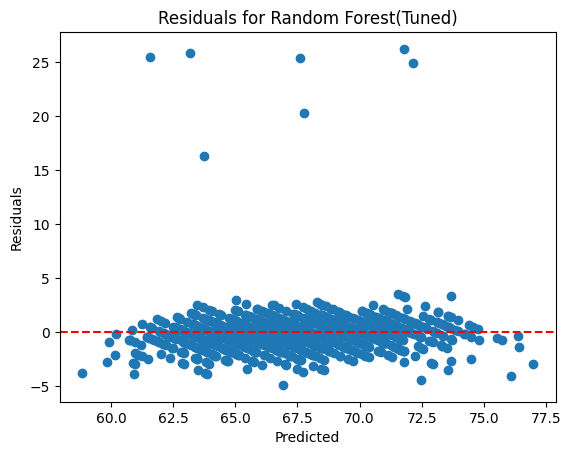

In [93]:
# create residual plot
residuals = y_test - pred_best_rf

# Plot
plt.scatter(pred_best_rf, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals for Random Forest(Tuned)')
plt.show()

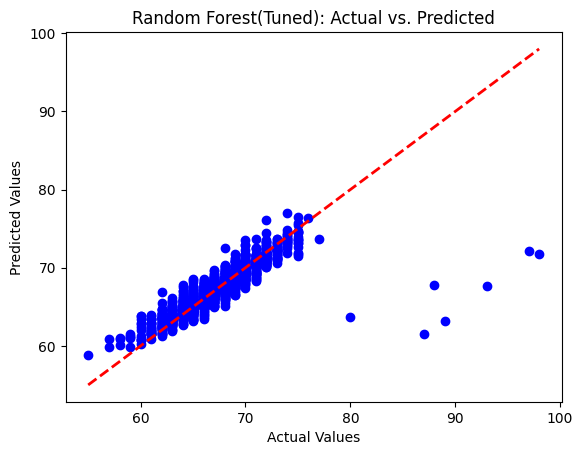

In [94]:
# plots of predicted values vs actual values

plt.scatter(y_test, pred_best_rf, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.title('Random Forest(Tuned): Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

Random Forest actually ferformed worse than Linear Regression. The releationship in the data is likely mostly linear but Random Forest tried too hard to learn the patterns in the training data( expecting the relationship to be more complicated) and ended up with overfitting issue. We can stil try XGBoost but at the stage we have the expectation that Linear Regression might be the best model after all.

### XGBoost

In [84]:
from xgboost import XGBRegressor

# create the basic model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
    )

# train the model
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


There will be a lot of parameters to test later.

In [85]:
# evaluation on teh test data
pred_xgb = xgb.predict(X_test)

# print the MSE and R squared
mse_xgb = mean_squared_error(y_test, pred_xgb)
r2_xgb = r2_score(y_test, pred_xgb)

# print the results
print("XGBoost")
print(f"XGBoost   Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost   R^2 Score: {r2_xgb:.2f}")

XGBoost
XGBoost   Mean Squared Error: 3.87
XGBoost   R^2 Score: 0.73


XGBoost performs better than Random Forest(though still slight worse than Linear Regression for this data).  

This is expected because Random Forest build trees in parallel and takes the mean of the results from all trees for regression tasks(reduces variance) while XGBoost builds trees sequentially and each tree corrects the error of the previous tree and has introcuded regularization and penalties to avoid overfitting problem (this way reduce both bias and variance).  

But it can be challenging as it has more parameters to tune.

In [87]:
# let's try to tune the XGBoost model
#param_grid_xgb = {
#    "n_estimators": [200, 400, 600],
#    "learning_rate": [0.01, 0.05, 0.1],
#    "max_depth": [2, 3, 4],
#    "min_child_weight": [1, 5, 10],
#    "subsample": [0.7, 0.8, 1.0],
#    "colsample_bytree": [0.7, 0.8, 1.0],
#    "reg_alpha": [0, 0.1, 1],
#    "reg_lambda": [1, 5, 10]
#}

#grid_xgb = GridSearchCV(
#    XGBRegressor(random_state=42),
#    param_grid_xgb,
#    cv=5,
#    scoring="r2",
#    n_jobs=-1
#)


# fit on training data to find the best parameters
#grid_xgb.fit(X_train, y_train)

#print("Best XGBoost Params:", grid_xgb.best_params_)

Originally, I wanted to use GridSearch for tuning but it appeared that it could take very long.  

It tuned out GridSearch is better when I have limited number of parameters to tune(like for Random Forest) and the search method is to try every single combination of the values. I couldn't use GridSearch here because for each of the many parameters, I want to test 3 values and the worload gets too big.  

So now I should use RandomizedSearch. It takes only a limited number(specified using n_iter) of pitential samples to test. While it can be argued that the best parameter here might not be the actual best but this tuning test can take foever if we really want a "best" result and it is worth it.

In [88]:
# let's try to tune the XGBoost model
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

grid_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror", # specify "reg" for regression task and "squaredeerror" as loss function
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# use the training data to find best parameters
grid_xgb.fit(X_train, y_train)

# print the best parameters
print("Best XGBoost Params:", grid_xgb.best_params_)

Best XGBoost Params: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [89]:
# create the tuned model
best_xgb = XGBRegressor(
    subsample = 0.7,
    reg_lambda = 10,
    reg_alpha = 0.1,
    n_estimators = 600,
    min_child_weight = 10,
    max_depth = 2,
    learning_rate = 0.05,
    colsample_bytree = 1.0,
    random_state=42
    )

# train the model
best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [91]:
# evaluate again
pred_best_xgb = best_xgb.predict(X_test)

# print the MSE and R squared
mse_best_xgb = mean_squared_error(y_test, pred_best_xgb)
r2_best_xgb = r2_score(y_test, pred_best_xgb)

# print the results
print("XGBoost")
print(f"XGBoost   Mean Squared Error: {mse_best_xgb:.2f}")
print(f"XGBoost   R^2 Score: {r2_best_xgb:.2f}")

XGBoost
XGBoost   Mean Squared Error: 3.40
XGBoost   R^2 Score: 0.76


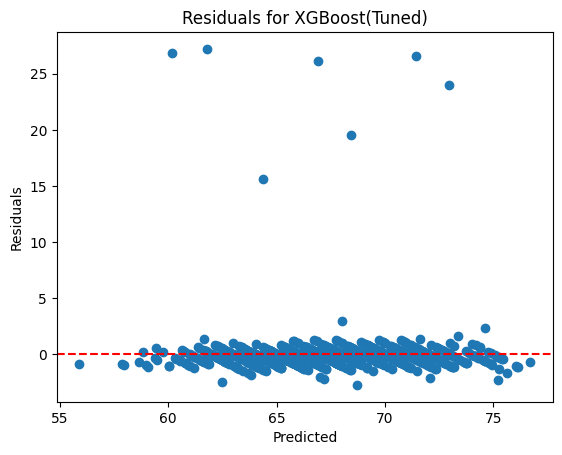

In [95]:
# create residual plot
residuals = y_test - pred_best_xgb

# Plot
plt.scatter(pred_best_xgb, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals for XGBoost(Tuned)')
plt.show()

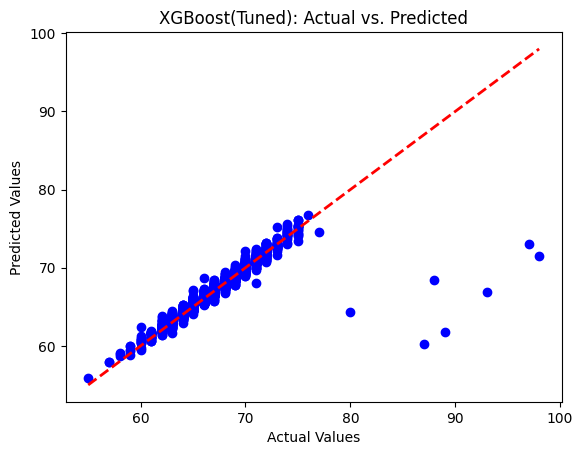

In [96]:
# plots of predicted values vs actual values

plt.scatter(y_test, pred_best_xgb, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.title('XGBoost(Tuned): Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

XGBoost after tuning is now performing similarly to Linear Regression though still slightly worse(MSE: 3.40 vs 3.26, R Square: 0.76 vs 0.77). 

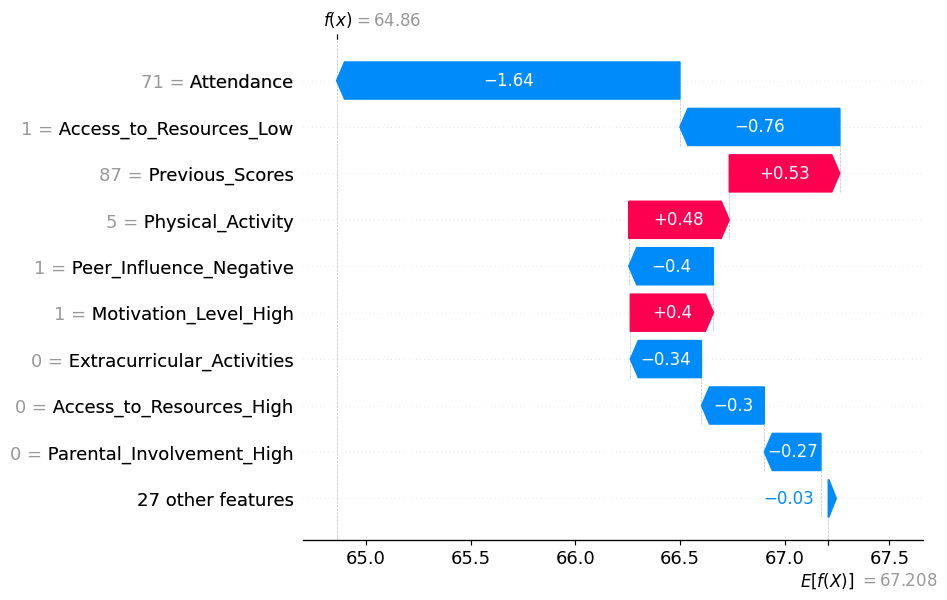

In [97]:
# use SHAP to visualize feature importance in tuned XGBoost
import shap
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)
shap.waterfall_plot(shap_values[0])

The waterfall plot show how all features contributes to the final prediction given by XGBoost Model on one single prediction.  

E[f(X)] = 67.208 is the baseline prediction and f(x) = 64.86 is the final prediction. The red and blue arrows explains how the features gradually push the baseline prediction to the final prediction. 

Apart from 27 features which are not listed independently, it appears that not having high parental involvement, high access to resources, no participation in extracurricular activities, nagative peer influence all lowers the expected score. Attendance rate(%) at 71  suggesting this student missing about 30% of his/her course has significant negative impact on the expected score.  

However, having a relatively good previous score(87), adequate physical activity(5, with value of this variable ranging from 0 to 6), high motivation increase the expected score though not offset the negative influences entirely which eventually set the prediction score at 64.86.

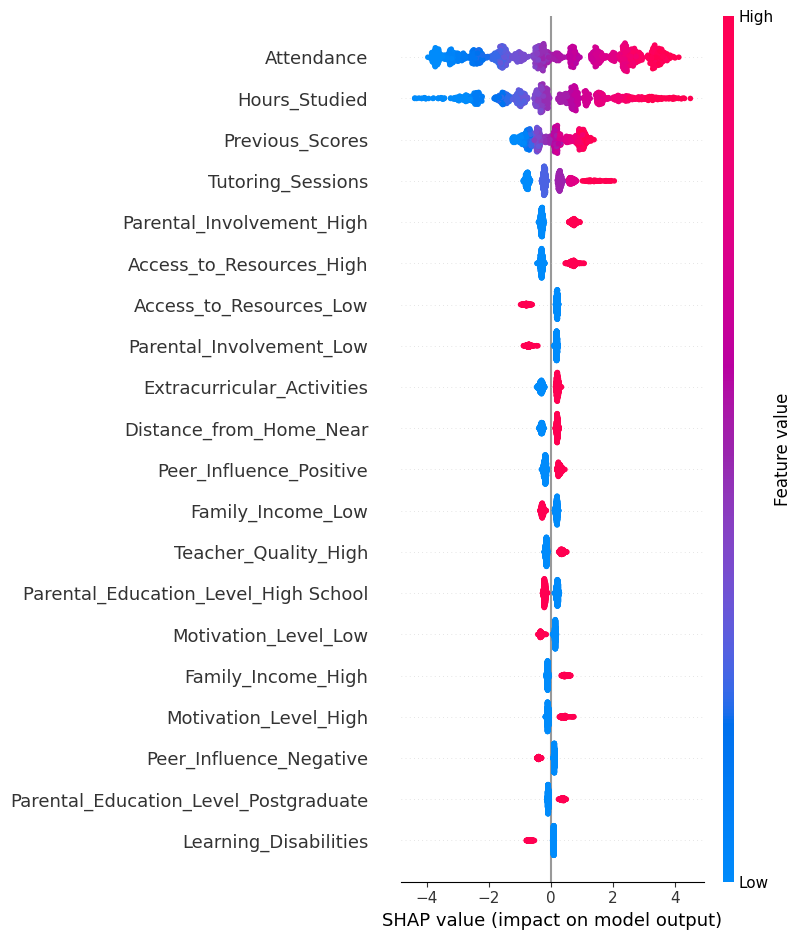

In [98]:
shap.summary_plot(shap_values, X_test)

In this plot, to push the expected score higher, the student require high attendance, more time invested in studying, higher previous score, more tutoring session, high parental involvement, high access to resources, participation in extracurricular activities, living closer to school(potentially reduce commuting time and increase time for study and rest), positive peer influence, high quality teacher, relatively high education level for parents(at least coollege degree), relatively high family income, high motivation and no learning disabilities.

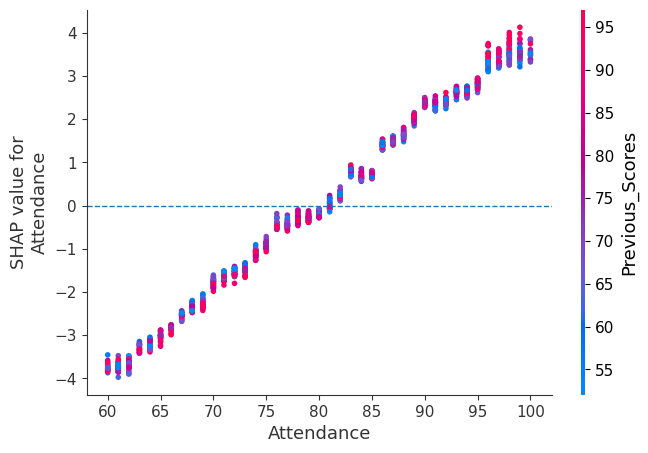

In [103]:
# in the waterfall plot, we see that the attendance rate 71% reduces the expected score
# use a dependence plot
shap.dependence_plot("Attendance", shap_values.values, X_test, show = False)
plt.axhline(0, linestyle="--", linewidth=1)
plt.show()

High attendance rate has a positive impact on the predicted score and the effect is mostly linear.

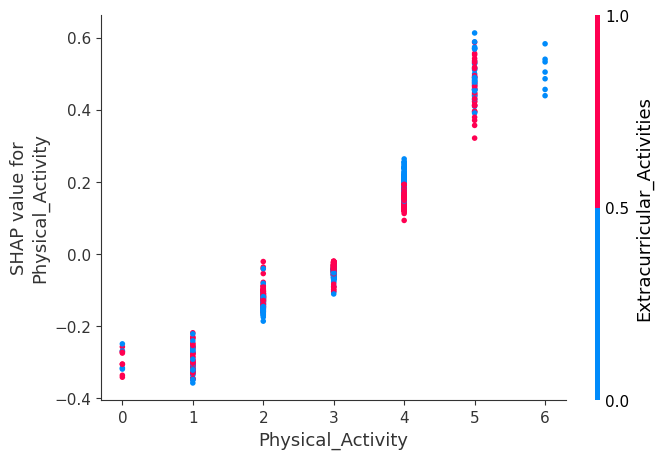

In [104]:
# do the same for Physocal_Activity
shap.dependence_plot("Physical_Activity", shap_values.values, X_test, show = False)

Having more physical activity is helpful to academic outcome when the value of this variable is greater than 4.

## Result from the best model(linear regression)

In [106]:
# get feature names and their coefficients
feature_names = X_train.columns
coef = linear.named_steps["linear"].coef_

# create result table
result_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

result_table

,Feature,Coefficient
1,Attendance,2.290134
0,Hours_Studied,1.756644
13,Access_to_Resources_High,1.044403
10,Parental_Involvement_High,1.024006
7,Physical_Activity,0.961041
3,Sleep_Hours,0.705671
4,Previous_Scores,0.625684
6,Tutoring_Sessions,0.582977
19,Family_Income_High,0.582079
16,Motivation_Level_High,0.532563


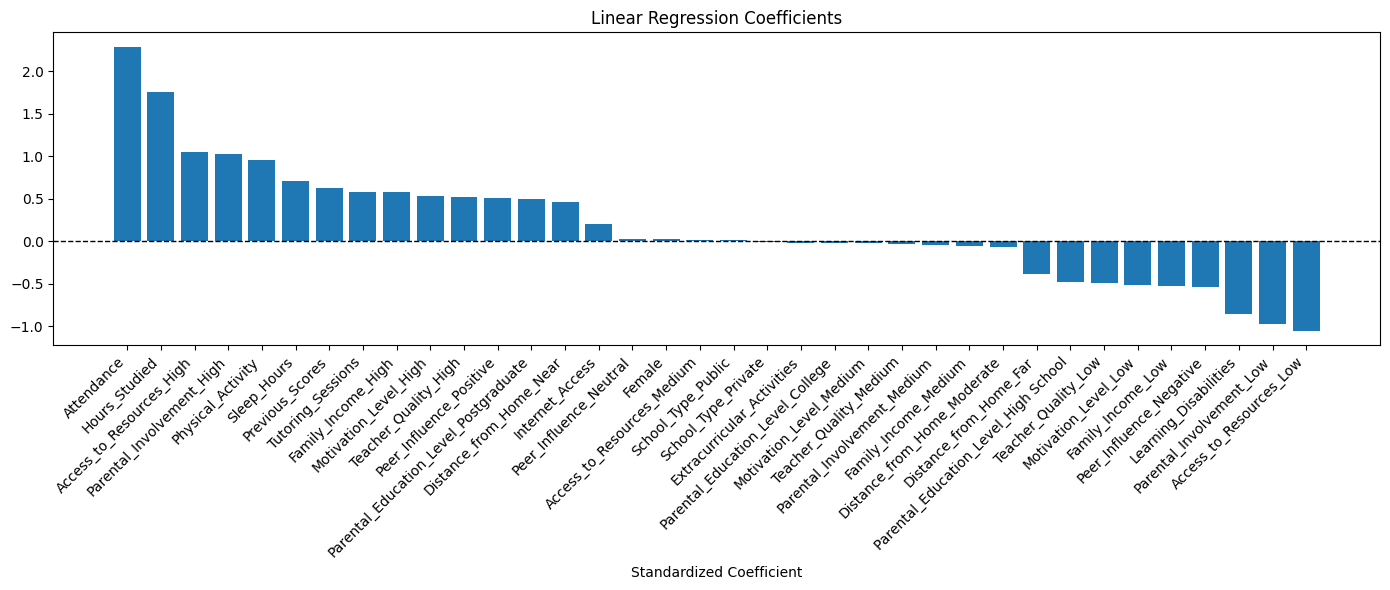

In [112]:
# visualize the coefficients
plt.figure(figsize=(14, 6))
plt.bar(result_table["Feature"], result_table["Coefficient"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Standardized Coefficient")
plt.title("Linear Regression Coefficients")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Again, for better academic outcome, the student will need  high attendance, more time invested in studying, higher previous score, more tutoring session, high parental involvement, high access to resources, participation in extracurricular activities, living closer to school(potentially reduce commuting time and increase time for study and rest), positive peer influence, high quality teacher, relatively high education level for parents(at least coollege degree), high family income(medium is not enough), high motivation and no learning disabilities.